# 08. Spatial Analysis

This notebook studies spatial patterns of groundwater levels using station coordinates.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## Load Feature-Engineered Dataset

In [2]:
candidate_paths = [
    Path("../datasets/groundwater_feature_engineered.csv"),
    Path("datasets/groundwater_feature_engineered.csv"),
    Path("groundwater_feature_engineered.csv")
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("groundwater_feature_engineered.csv not found in expected paths.")

df = pd.read_csv(dataset_path, parse_dates=["Data Acquisition Time"])

print(f"Dataset path: {dataset_path.resolve()}")
print("Shape:", df.shape)
print("Stations:", df["Station"].nunique())
df.head()

Dataset path: /content/groundwater_feature_engineered.csv
Shape: (69404, 25)
Stations: 18


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff,Year,Month,Day,...,Lag_1,Lag_4,Lag_28,RollingMean_4,RollingStd_4,Hour_sin,Hour_cos,Month_sin,Month_cos,Station_ID
0,Adakamaranahalli,2021-10-06 00:00:00,13.07,77.45,-22.50,849.0,1 days 06:00:00,2021,10,6,...,-22.71,-22.34,-22.51,-22.8625,0.419235,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0
1,Adakamaranahalli,2021-10-06 06:00:00,13.07,77.45,-22.83,849.0,0 days 06:00:00,2021,10,6,...,-22.50,-23.16,-22.87,-22.9025,0.355563,1.000000e+00,6.123234e-17,-1.0,-1.836970e-16,0
2,Adakamaranahalli,2021-10-06 12:00:00,13.07,77.45,-22.88,849.0,0 days 06:00:00,2021,10,6,...,-22.83,-23.24,-23.23,-22.8200,0.311448,1.224647e-16,-1.000000e+00,-1.0,-1.836970e-16,0
3,Adakamaranahalli,2021-10-06 18:00:00,13.07,77.45,-22.52,849.0,0 days 06:00:00,2021,10,6,...,-22.88,-22.71,-22.66,-22.7300,0.169115,-1.000000e+00,-1.836970e-16,-1.0,-1.836970e-16,0
4,Adakamaranahalli,2021-10-07 00:00:00,13.07,77.45,-22.35,849.0,0 days 06:00:00,2021,10,7,...,-22.52,-22.50,-22.46,-22.6825,0.200395,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0


## Station-Level Summary

For each station, we calculate average groundwater level and variability.

In [3]:
station_summary = (
    df.groupby("Station", as_index=False)
      .agg({
          "Latitude": "first",
          "Longitude": "first",
          "Groundwater Level Telemetry 6 Hourly (meter)": ["mean", "std", "min", "max", "count"]
      })
)

station_summary.columns = [
    "Station", "Latitude", "Longitude",
    "Avg_GW_Level", "Std_GW_Level", "Min_GW_Level", "Max_GW_Level", "Observations"
]

station_summary = station_summary.sort_values("Avg_GW_Level", ascending=False).reset_index(drop=True)
station_summary.head(10)

,Station,Latitude,Longitude,Avg_GW_Level,Std_GW_Level,Min_GW_Level,Max_GW_Level,Observations
0,Beguru_1,12.876944,77.625278,-0.538373,30.059189,-26.166,50.594,3528
1,Bagalagunte,13.060000,77.510000,-3.210812,21.614384,-54.137,54.911,4656
2,Devarabeesanahalli_1,12.923389,77.691778,-3.644486,5.355503,-43.081,1.000,3386
3,Sadashivanagara,13.010000,77.580000,-6.078176,2.261926,-9.223,12.457,4357
4,Thimmenahalli,12.980000,77.540000,-7.068891,26.219787,-38.206,79.026,4555
5,Adakamaranahalli,13.070000,77.450000,-9.839055,15.596862,-88.658,22.082,4566
6,Rajarajeshwari Nagara Pattanagere,12.920000,77.520000,-16.023956,3.078363,-18.671,1.000,4374
7,Marenahalli_1,12.970000,77.360000,-16.525802,1.813405,-18.893,1.000,3888
8,Tavarekere_1,12.960000,77.410000,-16.985354,3.870017,-23.850,1.000,2950
9,Chandapura_1,12.800000,77.710000,-19.581535,6.493275,-25.693,1.000,4594


## Station Locations (Scatter Plot)

Color shows average groundwater level. Bigger points mean higher variability.

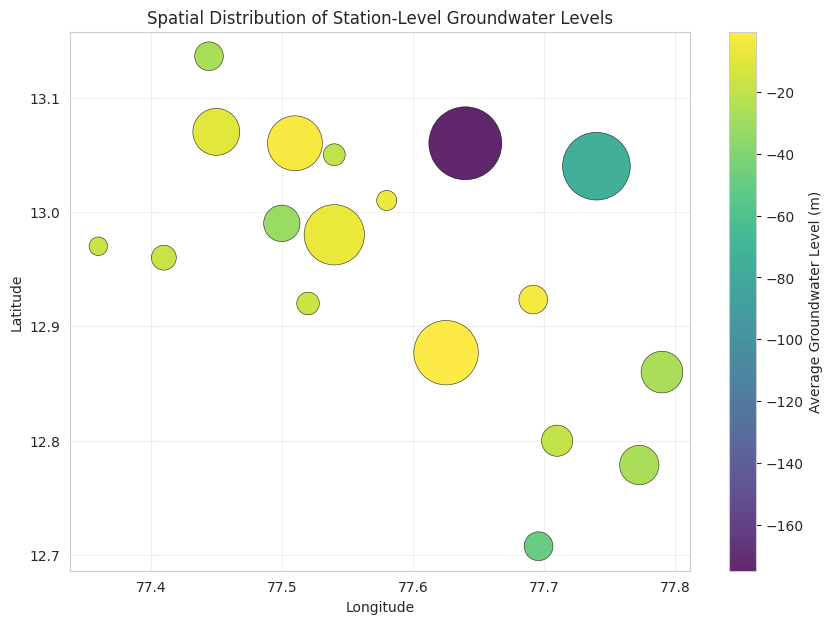

In [4]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    station_summary["Longitude"],
    station_summary["Latitude"],
    c=station_summary["Avg_GW_Level"],
    s=station_summary["Std_GW_Level"].fillna(0).clip(lower=0).values * 70 + 50,
    cmap="viridis",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4
)

plt.colorbar(scatter, label="Average Groundwater Level (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Station-Level Groundwater Levels")
plt.grid(alpha=0.3)
plt.show()

## Highest and Lowest Average Groundwater Stations

In [5]:
print("Top 5 stations (highest average groundwater level):")
display(station_summary[["Station", "Avg_GW_Level", "Std_GW_Level", "Observations"]].head(5))

print("Bottom 5 stations (lowest average groundwater level):")
display(station_summary[["Station", "Avg_GW_Level", "Std_GW_Level", "Observations"]].tail(5))

Top 5 stations (highest average groundwater level):


,Station,Avg_GW_Level,Std_GW_Level,Observations
0,Beguru_1,-0.538373,30.059189,3528
1,Bagalagunte,-3.210812,21.614384,4656
2,Devarabeesanahalli_1,-3.644486,5.355503,3386
3,Sadashivanagara,-6.078176,2.261926,4357
4,Thimmenahalli,-7.068891,26.219787,4555


Bottom 5 stations (lowest average groundwater level):


,Station,Avg_GW_Level,Std_GW_Level,Observations
13,Thotagere,-26.817666,5.372801,3044
14,Byadarahalli,-31.437619,9.073841,4584
15,Anekal_1,-48.284555,5.422195,2979
16,Avalahalli,-75.006859,33.237120,3082
17,K Narayanapura,-174.871330,38.691276,3289


## Latitude and Longitude Band Analysis

We split stations into simple north/south and west/east bands using median latitude and longitude.

In [6]:
lat_median = station_summary["Latitude"].median()
lon_median = station_summary["Longitude"].median()

station_summary["Lat_Band"] = np.where(station_summary["Latitude"] >= lat_median, "North", "South")
station_summary["Lon_Band"] = np.where(station_summary["Longitude"] >= lon_median, "East", "West")
station_summary["Region"] = station_summary["Lat_Band"] + "-" + station_summary["Lon_Band"]

region_summary = station_summary.groupby("Region", as_index=False).agg(
    Avg_GW_Level=("Avg_GW_Level", "mean"),
    Avg_Variability=("Std_GW_Level", "mean"),
    Stations=("Station", "count")
).sort_values("Avg_GW_Level", ascending=False)

region_summary

,Region,Avg_GW_Level,Avg_Variability,Stations
1,North-West,-16.348981,13.450572,6
3,South-West,-16.511704,2.920595,3
2,South-East,-20.814125,11.708188,6
0,North-East,-85.318788,24.730107,3


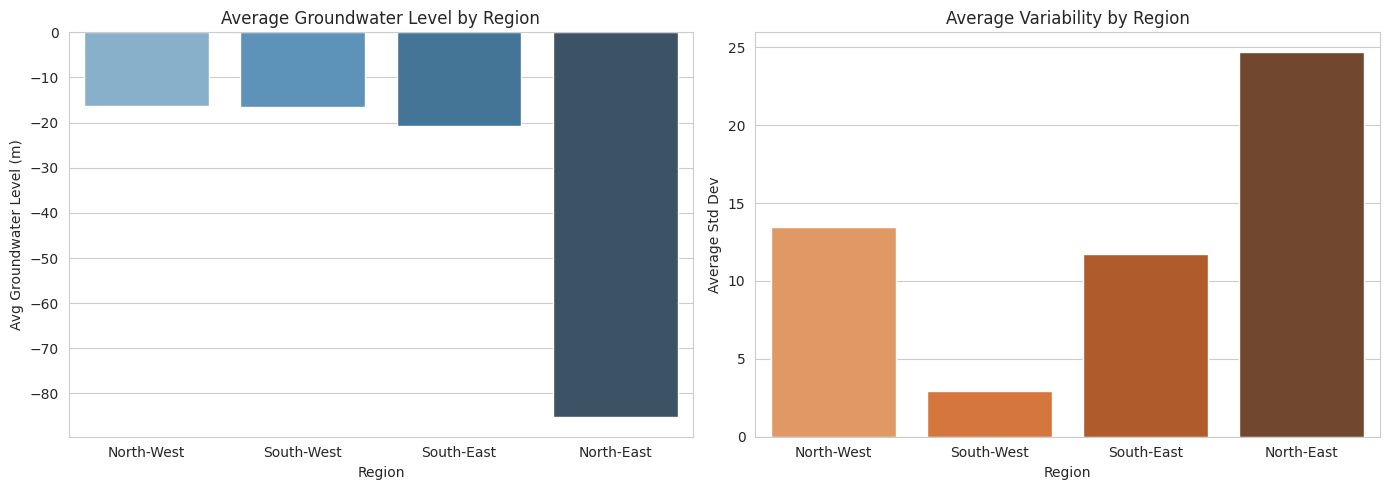

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_summary, x="Region", y="Avg_GW_Level", palette="Blues_d", ax=axes[0])
axes[0].set_title("Average Groundwater Level by Region")
axes[0].set_ylabel("Avg Groundwater Level (m)")

sns.barplot(data=region_summary, x="Region", y="Avg_Variability", palette="Oranges_d", ax=axes[1])
axes[1].set_title("Average Variability by Region")
axes[1].set_ylabel("Average Std Dev")

for ax in axes:
    ax.set_xlabel("Region")

plt.tight_layout()
plt.show()

## Link to Prediction Task

Spatial differences show that stations behave differently in both level and variability.
This supports using location features (Latitude, Longitude, Station_ID) in the ML models to improve prediction quality.